In [1]:
import pandas as pd
import numpy as np
import skimage as sk

In [17]:
import os
import ultraplot as uplt

In [115]:
dataloc ="../data/validation_dataset/binary_floes_init/"
files = os.listdir(dataloc)
files.sort()
files = [f for f in files if 'DS_' not in f]

# Checking images and summarizing floe statistics
* Enforce global minimum size of 64 pixels (8 by 8)
* Get minimum, maximum, mean, and count

In [116]:
binary_images = {}
for f in files:
    case, region, date, satellite, imtype = f.split('-')
    case_name = case + '_' + satellite
    binary_images[case_name] = sk.io.imread(dataloc + f)

In [117]:
floe_stats = {}
for case_name in binary_images:
    if np.any(binary_images[case_name][:,:,0] > 0):
        labeled = sk.measure.label(binary_images[case_name][:, :, 0])
        df = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))
        floe_stats[case_name] = [df.area.min(), df.area.mean(), df.area.max(), len(df)]
        
floe_stats = pd.DataFrame(floe_stats).T
floe_stats.columns = ["minimum", "mean", "maximum", "count"]

In [118]:
case_name = '006_terra'
labeled = sk.measure.label(binary_images[case_name][:, :, 0])
df = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))
[df.area.min(), df.area.mean(), df.area.max(), len(df)]

[np.float64(17.0), np.float64(282.26881720430106), np.float64(3436.0), 186]

In [119]:
floe_stats.loc[floe_stats.minimum < min_area]

,minimum,mean,maximum,count
001_aqua,47.0,610.181818,4127.0,11.0
001_terra,50.0,629.636364,4296.0,11.0
005_aqua,35.0,153.823529,951.0,17.0
005_terra,27.0,159.666667,924.0,24.0
006_aqua,21.0,286.401130,3461.0,177.0
...,...,...,...,...
171_terra,15.0,36.750000,73.0,4.0
175_aqua,43.0,52.000000,61.0,2.0
188_terra,49.0,77.250000,133.0,4.0
189_aqua,27.0,81.142857,137.0,7.0


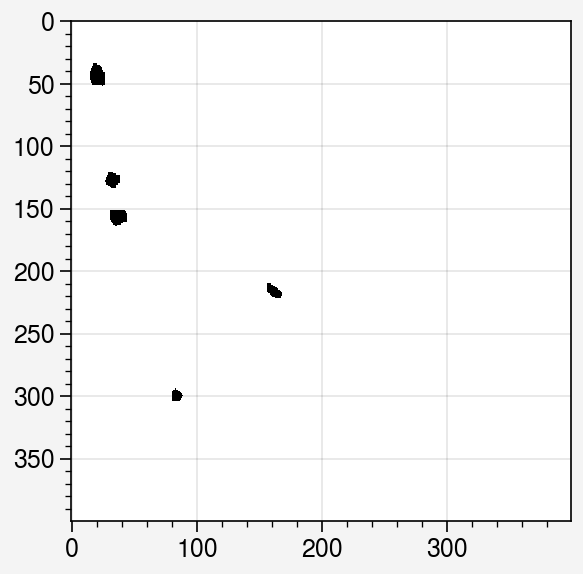

In [120]:
# Highlight floe which is too small
case_name = '008_terra'
min_area = 64

fig, ax = uplt.subplots()
labeled = sk.measure.label(binary_images[case_name][:,:,0])
updated = labeled.copy()

df = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))

ax.imshow(np.ma.masked_array(labeled, mask=labeled == 0), color='k')
for label in df.loc[df.area < min_area, 'label']:
    updated[updated == label] = 0
    ax.imshow(np.ma.masked_array(labeled, mask=labeled != label), color='r')
    ax.format(ltitle=case_name, xticks='none', yticks='none')

In [66]:
[df.area.min(), df.area.mean(), df.area.max(), len(df)]

[np.float64(17.0), np.float64(263.25), np.float64(3436.0), 176]

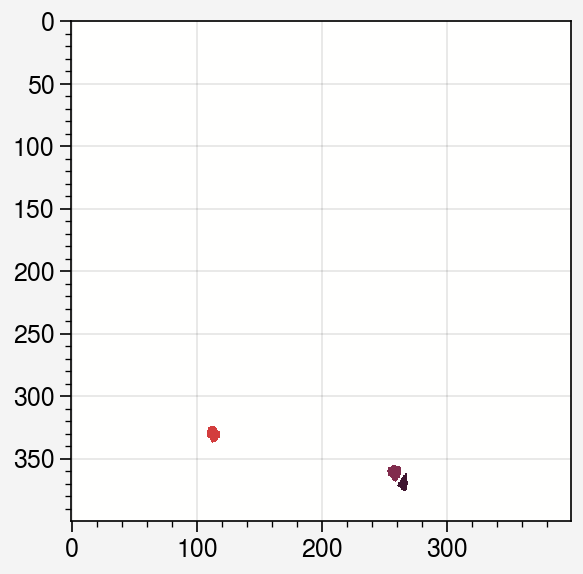

In [43]:
fig, ax = uplt.subplots()
ax.imshow(updated)

In [121]:
saveloc = '../data/validation_dataset/binary_floes'
min_area = 64
for f in files:
    case, region, date, satellite, imtype = f.split('-')
    case_name = case + '_' + satellite

    labeled = sk.measure.label(binary_images[case_name][:,:,0])
    updated = labeled.copy()
    df = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))
    if np.any(df.area.min() < min_area):
        for label in df.loc[df.area < min_area, 'label']:
            updated[updated == label] = 0
        
    sk.io.imsave(saveloc + '/' + f, (updated > 0).astype(np.uint8)*255)

/opt/miniconda3/envs/ift_jog/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: ../data/validation_dataset/binary_floes/004-baffin_bay-20190925-aqua-binary_floes.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/ift_jog/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: ../data/validation_dataset/binary_floes/004-baffin_bay-20190925-terra-binary_floes.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/ift_jog/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: ../data/validation_dataset/binary_floes/008-baffin_bay-20110506-terra-binary_floes.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/ift_jog/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: ../data/validation_dataset/binary_floes/015-baffin_bay-20210804-aqua-binary_floes.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/ift_jog/l